[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/01_eda.ipynb)

# 01 — What the Data Says About the Problem

**Question.** How do the three bands behave, where is the demand, and is the data fit to optimize on?

**Inputs.** The simulation artifacts from notebook 00, read-only. **Outputs.** Tables and figures in `reports/`; no data.
No GPU is needed.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.data.load import load_artifacts
from src.evaluation import compare, maps, plots
from src.evaluation.export import readable, save_table
from src.kpi import capacity
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/01_eda"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/01_eda"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

In [3]:
artifacts = load_artifacts(cfg)
mdt, ue, manifest = artifacts.mdt, artifacts.ue, artifacts.manifest
radio_map = artifacts.radio
rsrp = radio_map["rsrp_dbm"].astype(float)
sinr = radio_map["sinr_db"].astype(float)
bands, tx_names = artifacts.band_labels, artifacts.tx_names
n_rows, n_cols = artifacts.shape
hole_dbm, weak_dbm = float(cfg.kpi.hole_dbm), float(cfg.kpi.weak_dbm)

cells = pd.DataFrame(
    [
        {"cell": str(c.name), "x": float(c.x), "y": float(c.y), "azimuth_deg": float(c.azimuth_deg)}
        for c in cfg.simulation.transmitters.cells
    ]
)
hotspots = pd.DataFrame(manifest["density"]["hotspots"])

## 1. Dataset Overview

In [4]:
overview = (
    pd.DataFrame(
        {
            "Value": {
                "Sites": cells.assign(site=cells["cell"].str.rsplit("c", n=1).str[0])[
                    "site"
                ].nunique(),
                "Cells": len(tx_names),
                "Frequency bands": len(bands),
                "Decision variables (cell-band tilts)": len(tx_names) * len(bands),
                "Grid tiles": n_rows * n_cols,
                "Time intervals": int(manifest["time"]["n_intervals"]),
                "UE positions": len(ue),
                "MDT reports": len(mdt),
            }
        }
    )
    .rename_axis("Property")
    .reset_index()
)
save_table(overview, "dataset_overview")
overview

,Property,Value
0,Sites,4
1,Cells,12
2,Frequency bands,3
3,Decision variables (cell-band tilts),36
4,Grid tiles,101060
5,Time intervals,672
6,UE positions,10066
7,MDT reports,9929


## 2. The Role of Each Band

Signal strength and reach against distance from the cell. Lower bands are expected to reach
farther; the question is by how much in this city.

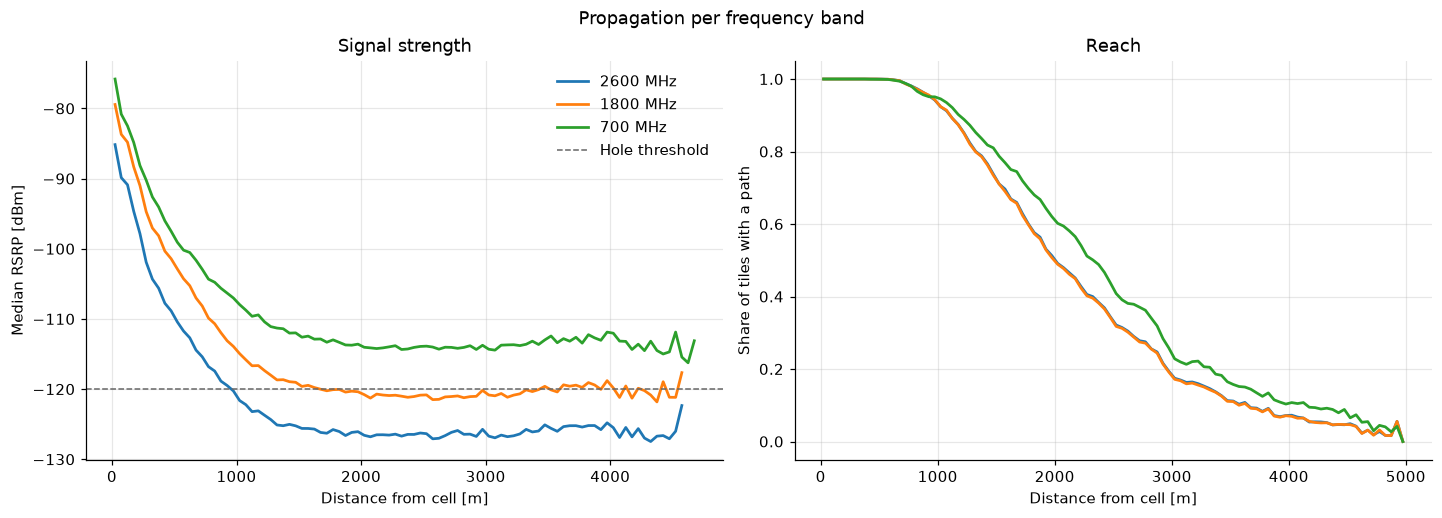

In [5]:
xs = float(radio_map["origin_x"]) + (np.arange(n_cols) + 0.5) * float(radio_map["tile_size_m"])
ys = float(radio_map["origin_y"]) + (np.arange(n_rows) + 0.5) * float(radio_map["tile_size_m"])
grid_x, grid_y = np.meshgrid(xs, ys)
distance = np.stack([np.hypot(grid_x - row.x, grid_y - row.y) for row in cells.itertuples()])
edges = np.arange(0.0, distance.max() + 50.0, 50.0)
midpoints = 0.5 * (edges[:-1] + edges[1:])
which_bin = np.digitize(distance, edges) - 1
MIN_TILES = 30  # bins with fewer reached tiles are not drawn

figure, axes = plt.subplots(1, 2, figsize=(13.0, 4.6), constrained_layout=True)
for index, band in enumerate(bands):
    layer = rsrp[index]
    reached = np.isfinite(layer)
    medians, shares = [], []
    for bin_index in range(len(midpoints)):
        in_bin = which_bin == bin_index
        hit = in_bin & reached
        medians.append(np.median(layer[hit]) if hit.sum() >= MIN_TILES else np.nan)
        shares.append(hit.sum() / in_bin.sum() if in_bin.any() else np.nan)
    axes[0].plot(midpoints, medians, lw=1.8, label=label(band))
    axes[1].plot(midpoints, shares, lw=1.8, label=label(band))
axes[0].axhline(hole_dbm, color="0.4", ls="--", lw=1, label="Hole threshold")
axes[0].set(xlabel="Distance from cell [m]", ylabel="Median RSRP [dBm]", title="Signal strength")
axes[1].set(xlabel="Distance from cell [m]", ylabel="Share of tiles with a path", title="Reach")
axes[0].legend()
figure.suptitle("Propagation per frequency band")
save_fig(figure, "band_propagation")
plt.show()

In [6]:
best_per_band = np.stack([capacity.max_rsrp(rsrp[[i]]) for i in range(len(bands))])
best_overall = capacity.max_rsrp(rsrp)


def classes(best):
    """Share of tiles per coverage class, in percent."""
    return {
        "Coverage holes [%]": 100.0 * (best <= hole_dbm).mean(),
        "Weak coverage [%]": 100.0 * ((best > hole_dbm) & (best <= weak_dbm)).mean(),
        "Good coverage [%]": 100.0 * (best > weak_dbm).mean(),
    }


coverage_classes = pd.DataFrame(
    [{"Layer": label(band), **classes(best_per_band[i])} for i, band in enumerate(bands)]
    + [{"Layer": "All bands combined", **classes(best_overall)}]
)
save_table(coverage_classes, "coverage_classes_per_band")
coverage_classes

,Layer,Coverage holes [%],Weak coverage [%],Good coverage [%]
0,2600 MHz,35.0188,46.5882,18.3930
1,1800 MHz,29.9664,43.3742,26.6594
2,700 MHz,19.8704,32.5341,47.5955
3,All bands combined,16.1854,34.9100,48.9046


**Observations.** _To be written._

## 3. Demand Against Coverage

Peak Physical Resource Block (PRB) demand per tile, next to signal strength. The table compares the
share of **area** in each coverage class, which the hole and weak rates count, with the share of **demand** in it.

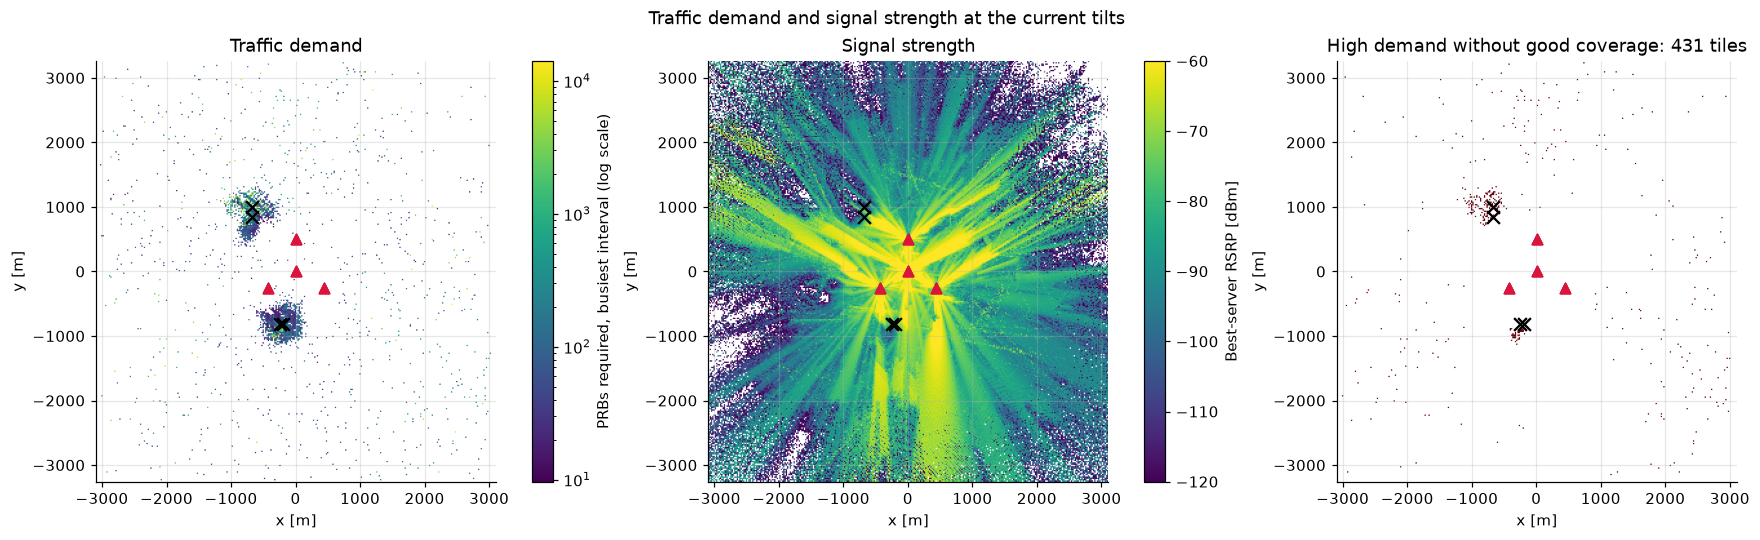

,Coverage class,Tiles,Share of area,Peak PRB demand,Share of demand
0,hole,16357,0.1619,0.0000,0.0000
1,weak,35280,0.3491,985924.5747,0.7724
2,good,49423,0.4890,290528.8492,0.2276


In [7]:
peak_prb = capacity.demand_prb(rsrp, sinr, bands, mdt, cfg)
figure = plots.demand_signal_maps(rsrp, peak_prb, radio_map, cfg, cells=cells, hotspots=hotspots)
figure.suptitle("Traffic demand and signal strength at the current tilts")
save_fig(figure, "demand_vs_coverage")
plt.show()

area_vs_demand = readable(maps.coverage_table(rsrp, peak_prb, cfg))
save_table(area_vs_demand, "coverage_by_area_and_demand")
area_vs_demand

**Observations.** _To be written._

## 4. Serving Band and Cell Load

Each UE report is assigned a serving cell-band by the capacity model in `src/kpi/capacity.py`
(preferred band first, subject to per-cell PRB limits). Its settings are placeholders (`configs/kpi.yaml`).

,Serving band,Share of UE reports
0,2600 MHz,0.5373
1,1800 MHz,0.1404
2,700 MHz,0.0962
3,Not served,0.2261


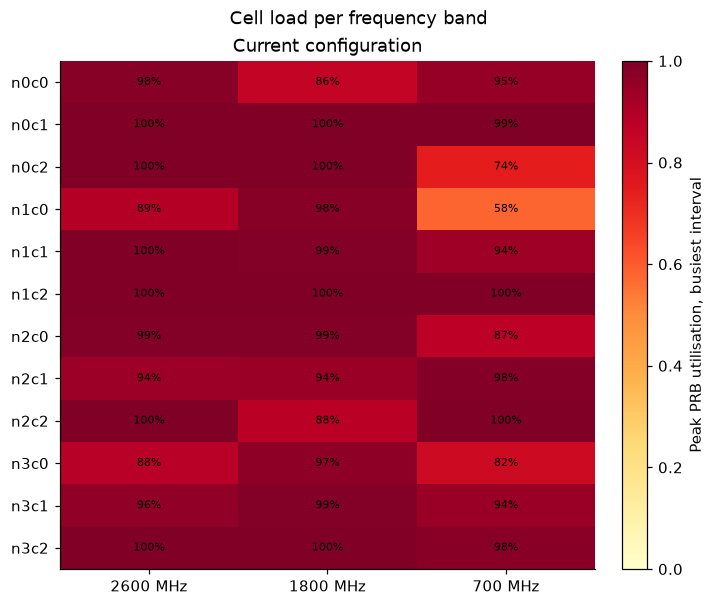

In [8]:
served = capacity.serve_intervals(rsrp, sinr, bands, mdt, cfg)
service = compare.service_summary(served, bands)
serving_mix = pd.DataFrame(
    [
        {"Serving band": label(band), "Share of UE reports": service[f"share_{band}"]}
        for band in bands
    ]
    + [{"Serving band": "Not served", "Share of UE reports": service["not_served_share"]}]
)
save_table(serving_mix, "serving_band_mix")
display(serving_mix)

max_prb = capacity.CapacitySpec.from_config(cfg, bands, len(tx_names)).max_prb
load = compare.cell_band_load(served, bands, tx_names, max_prb)
figure = plots.utilisation_heatmaps({"incumbent": load})
save_fig(figure, "cell_band_utilisation")
plt.show()

**Observations.** _To be written._

## 5. Data Quality

Each check names the reference its bound comes from. Nothing is removed here; the table states what the
optimization inherits.

In [9]:
values = mdt[artifacts.measurement_columns].to_numpy()
reported = values[np.isfinite(values)]

# [band, tx, ue] -> [ue, tx, band], flattened tx-major and band-minor like the MDT columns.
clean = rsrp[:, :, mdt["tile_row"].to_numpy(), mdt["tile_col"].to_numpy()]
clean = clean.transpose(2, 1, 0).reshape(len(mdt), -1)
both = np.isfinite(clean) & np.isfinite(values)
residual = values[both] - clean[both]
sigma = float(cfg.simulation.mdt.rsrp_noise_sigma_db)

quality = pd.DataFrame(
    [
        (
            "Reported RSRP below -156 dBm",
            "NR SS-RSRP reporting range lower bound, 3GPP TS 38.133 (to be verified)",
            f"{(reported < -156.0).mean():.2%} of measurements",
        ),
        (
            "Reported RSRP above the reference-signal transmit power",
            "configs/simulation.yaml simulation.antenna.power_rs",
            f"{(reported > float(cfg.simulation.antenna.power_rs)).mean():.2%} of measurements",
        ),
        (
            "UEs dropped because no cell reached them",
            "src/simulation/mdt.py",
            f"{(len(ue) - len(mdt)) / len(ue):.2%} of UEs",
        ),
        (
            "UE reports blocked by PRB limits",
            "configs/kpi.yaml capacity (placeholder values)",
            f"{service['not_served_share']:.2%} of reports",
        ),
        (
            "Measurement error recovered from MDT minus radio map",
            f"configs/simulation.yaml simulation.mdt.rsrp_noise_sigma_db = {sigma:g} dB",
            f"mean {residual.mean():+.2f} dB, standard deviation {residual.std():.2f} dB",
        ),
    ],
    columns=["Check", "Reference", "Result"],
)
save_table(quality, "data_quality")
quality

,Check,Reference,Result
0,Reported RSRP below -156 dBm,"NR SS-RSRP reporting range lower bound, 3GPP T...",4.58% of measurements
1,Reported RSRP above the reference-signal trans...,configs/simulation.yaml simulation.antenna.pow...,0.00% of measurements
2,UEs dropped because no cell reached them,src/simulation/mdt.py,1.36% of UEs
3,UE reports blocked by PRB limits,configs/kpi.yaml capacity (placeholder values),22.61% of reports
4,Measurement error recovered from MDT minus rad...,configs/simulation.yaml simulation.mdt.rsrp_no...,"mean +0.00 dB, standard deviation 4.00 dB"


**Observations.** _To be written._